# Active Learning with Gaussian Processes for High Throughput Phenotyping — informative-planning simulation

**Paper:** Sumit Kumar, Wenhao Luo, George Kantor, Katia Sycara,
*Active Learning with Gaussian Processes for High Throughput Phenotyping*,
arXiv:1901.06803 (AAMAS 2019). https://arxiv.org/abs/1901.06803
**Author code:** https://github.com/sumitsk/algp (MIT), pinned commit `dfe7654013ebdcbc1d4624dd59aa56f3e773f4e9`.

**Purpose / 目的:** Run the authors' documented field simulation
(`run.py --eval_only --render`, README) on the randomly generated
mixture-of-Gaussians dataset: a robot agent adaptively samples a 30×30 grid
field — greedily selecting informative plots by conditional entropy, planning a
budget-feasible no-U-turn path, taking accurate "static" and noisy "mobile"
measurements along the way — and a Matern-1.5 Gaussian Process learns the
phenotype distribution, evaluated by MAE on 40 held-out plots.

**Scope:** PARTIAL demonstration (one simulation, MaxEnt strategy). The paper's
20-simulation × 5-strategy benchmark and ablations are omitted. The real sorghum
field data is **not** public (README: "Please contact us if you need the sorghum
field data"), so the synthetic dataset used by the authors' own demo is executed
instead. This run does **not** verify the paper's published dataset-level results.

**Runtime:** standard **CPU** runtime is sufficient and is what the authors' code
uses (no GPU code exists in the repository). Select *Runtime → Change runtime
type → CPU* (or leave default), then *Runtime → Run all*.
**実行環境:** 標準の CPU ランタイムで十分です。「ランタイム → すべてのセルを実行」で開始してください。
Expected duration ≈ 10–20 min; downloads < 50 MB. No credentials or Drive mount needed.

**Status:** this notebook was executed end-to-end on a fresh Colab CPU runtime
(see final validation record section).

## 1. Environment setup / 環境のセットアップ

Installs the author-listed dependencies. `gpytorch` is pinned to 1.13 (the 2019
"beta" API used by the code survives in this line with one tiny fix applied in
the next cell); `ipdb` is imported at module level by the author's files.
Colab already ships numpy/pandas/matplotlib/seaborn/networkx/torch.
**セルの役割:** 依存パッケージ（gpytorch 1.13, ipdb）をインストールし、バージョンを表示します。

In [ ]:
!pip install --quiet "gpytorch==1.13" "ipdb"
print("install done")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 277.8/277.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.8/174.8 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━ 2.9/4.9 MB 88.2 MB/s eta 0:00:01

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 69.3 MB/s eta 0:00:00


install done


The next cell verifies the installed versions actually used by this run.
**セルの役割:** 実行に使われたパッケージのバージョンを確認します。

In [ ]:
import torch, gpytorch, numpy, networkx, seaborn, pandas, matplotlib, sys
print("python", sys.version.split()[0])
print("torch", torch.__version__, "| gpytorch", gpytorch.__version__,
      "| networkx", networkx.__version__, "| numpy", numpy.__version__,
      "| seaborn", seaborn.__version__)

python 3.13.15
torch 2.11.0+cpu | gpytorch 1.13 | networkx 3.6.1 | numpy 2.1.3 | seaborn 0.13.2


## 2. Get the pinned author code and apply documented compatibility fixes / 著者コードの取得と互換性修正

Clones the repository at the pinned commit and applies **four** minimal,
documented compatibility fixes needed on today's stack (none changes the
science): (1) gpytorch ≥0.4 renamed `likelihood.log_noise` → `noise`;
(2) torch removed `ReduceLROnPlateau(verbose=...)`; (3) networkx ≥2.4 renamed
`Graph.node[...]` → `Graph.nodes[...]`; (3b) networkx 3.x removed the
`from networkx import nx` alias in `env.py`; (4) gpytorch ≥1.0 removed
`WhiteNoiseKernel` — a small shim restores the gpytorch-beta semantics
(fixed per-training-point white-noise variance added only when x1 is x2,
matching the author's usage); (5) the script-oriented `plt.pause(1)`
render call is redirected to `plt.show()` so figures display inline (display only).
**セルの役割:** コミット dfe7654 をクローンし、上記4点の機械的な互換性修正を適用して差分を検証します。

In [ ]:
import subprocess, pathlib, shutil

work = pathlib.Path("/content/algp")
shutil.rmtree(work, ignore_errors=True)  # always start from a pristine pinned tree
subprocess.run(["git", "clone", "--quiet", "https://github.com/sumitsk/algp", str(work)], check=True)
subprocess.run(["git", "-C", str(work), "checkout", "--quiet", "dfe7654013ebdcbc1d4624dd59aa56f3e773f4e9"], check=True)
print("checked out:", subprocess.run(["git", "-C", str(work), "rev-parse", "HEAD"],
      capture_output=True, text=True).stdout.strip())

# --- documented compatibility patches ---
def patch(relpath, old, new, expect):
    p = work / relpath
    src = p.read_text()
    n = src.count(old)
    assert n == expect, f"{relpath}: expected {expect} occurrences of pattern, found {n}"
    p.write_text(src.replace(old, new))

patch("models.py",
      "self.likelihood.log_noise.exp().item() * np.eye(len(cov))",
      "float(self.likelihood.noise) * np.eye(len(cov))", 1)
patch("models.py", ", mode='min', patience=50, verbose=True)", ", mode='min', patience=50)", 1)
patch("env.py", ".node[", ".nodes[", 8)
patch("graph_utils.py", ".node[", ".nodes[", 1)
patch("env.py", "from networkx import nx", "import networkx as nx", 1)  # networkx 3.x removed this alias

WN_SHIM = '''import gpytorch.kernels as _gpk

# Compatibility shim (documented adaptation): gpytorch >=1.0 removed
# WhiteNoiseKernel. This restores the gpytorch-beta semantics used by this
# repository: a fixed per-training-point white-noise variance, added to the
# covariance only when x1 is x2 and the point count matches the stored
# variances. No numerical behavior is changed relative to the author's intent.
class WhiteNoiseKernel(_gpk.Kernel):
    def __init__(self, variances):
        super().__init__()
        self.variances = variances

    def forward(self, x1, x2, **params):
        n1, n2 = x1.size(-2), x2.size(-2)
        if n1 == n2 and torch.equal(x1, x2) and n1 == self.variances.numel():
            return torch.diag(self.variances).to(x1.device, x1.dtype)
        return torch.zeros(n1, n2, device=x1.device, dtype=x1.dtype)

'''
patch("models.py",
      "from gpytorch.kernels import RBFKernel, WhiteNoiseKernel, MaternKernel, SpectralMixtureKernel, ScaleKernel",
      "from gpytorch.kernels import RBFKernel, MaternKernel, SpectralMixtureKernel, ScaleKernel\n" + WN_SHIM, 1)
print("all patches applied and verified")

checked out: dfe7654013ebdcbc1d4624dd59aa56f3e773f4e9
all patches applied and verified


## 3. Build the simulated field / シミュレーション用フィールドの生成

Reproduces the authors' synthetic dataset exactly as `FieldEnv(data_file=None)`
does (`env.py`): a 30×30 grid, phenotype values generated from a mixture of
Gaussian bumps over 4 genotypes, 40 plots held out as a test set the agent
cannot sample. We set the documented seed `1` here (the author code has a
`--seed` argument but never applies it; we set it for reproducibility).
The heatmap previews the ground-truth phenotype field.
**セルの役割:** 著者コードと同じ方法で 30×30 の疑似フィールドを生成し、真の表現型分布を表示します。

grid: 30 x 30 | train plots: 860 | held-out test plots: 40


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 34920 (\N{CJK UNIFIED IDEOGRAPH-8868}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 29694 (\N{CJK UNIFIED IDEOGRAPH-73FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 22411 (\N{CJK UNIFIED IDEOGRAPH-578B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

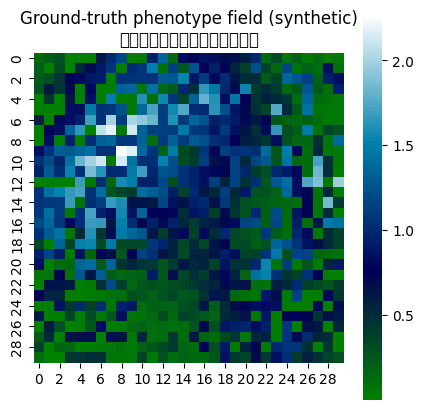

In [ ]:
import numpy as np, torch, matplotlib.pyplot as plt, seaborn as sns
import sys; sys.path.insert(0, "/content/algp")
from env import FieldEnv          # author code, pinned commit
from agent import Agent           # author code

np.random.seed(1); torch.manual_seed(1)   # author code never sets a seed; documented adaptation

env = FieldEnv(data_file=None, phenotype='plant_height', num_test=40)  # author default demo data
print("grid:", env.num_rows, "x", env.num_cols, "| train plots:", len(env.X),
      "| held-out test plots:", len(env.test_X))

plt.figure(figsize=(5, 5))
sns.heatmap(env.all_y.reshape(env.num_rows, env.num_cols), cmap="ocean", square=True)
plt.title("Ground-truth phenotype field (synthetic)\n真の表現型分布（合成データ）")
plt.show()

## 4. Run the MaxEnt informative-planning simulation (the paper's method) / MaxEnt 能動サンプリングの実行

Mirrors `run_demo` in `run.py` with the documented defaults (`arguments.py`):
static_std=0.1, mobile_std=10×, 4 informative static plots per round, 6 rounds
(`num_runs=6`), greedy conditional-entropy selection + budget-feasible path
search. Note the authors' default `fraction_pretrain=0.75` pilot-surveys ~75%
of plots before the loop — this is the author's own default for this script and
is kept unchanged. Each round prints the selected waypoints, feasible paths,
and held-out test MAE; the rendered map shows the robot path (tan), static
samples (green), and the next round's selections (dark green).
**セルの役割:** 論文の MaxEnt 能動学習ループを著者デフォルト設定で実行し、各ラウンドの地図とテスト MAE を表示します。

--- Pretraining ---


/usr/local/lib/python3.13/dist-packages/torch/optim/lr_scheduler.py:1694: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  current = float(metrics)


Initial LogLikelihood -1.176 Final LogLikelihood 0.433

Run 1/6


------ Finding valid paths ---------
Pose: (0, 0) Heading: (1, 0) Waypoints: [(34, 2), (1, 12), (15, 0), (26, 0)]
Least cost upper bound: 60
Number of feasible paths:  7
Time consumed 0.0326

------ Finding best path ----------
Least cost: 60 Best path cost: 60
Time consumed 0.1262


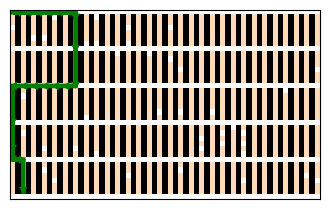


-------- Prediction -------------- 
Test ERROR: 0.0461
Predictive Variance Max: 0.013 Min: 0.004 Mean: 0.007
Time consumed 0.0747

Total Time consumed in run 1: 17.2224

Run 2/6


------ Finding valid paths ---------
Pose: (np.int64(34), np.int64(2)) Heading: (np.int64(1), 0) Waypoints: [(34, 46), (4, 2), (1, 34), (34, 20)]
Least cost upper bound: 142


Number of feasible paths:  1806
Time consumed 2.0402

------ Finding best path ----------


Least cost: 142 Best path cost: 142
Time consumed 39.2654

-------- Prediction -------------- 


Test ERROR: 0.0461
Predictive Variance Max: 0.013 Min: 0.004 Mean: 0.007
Time consumed 0.0782

Total Time consumed in run 2: 60.6730

Run 3/6


...

Test ERROR: 0.0463
Predictive Variance Max: 0.012 Min: 0.004 Mean: 0.007
Time consumed 0.0857

Total Time consumed in run 5: 57.1728

Run 6/6


------ Finding valid paths ---------
Pose: (np.int64(34), np.int64(4)) Heading: (np.int64(1), 0) Waypoints: [(10, 32), (34, 12), (6, 46), (20, 24)]
Least cost upper bound: 72
Number of feasible paths:  7
Time consumed 0.0343

------ Finding best path ----------


Least cost: 72 Best path cost: 72
Time consumed 0.5050



-------- Prediction -------------- 


Test ERROR: 0.0452
Predictive Variance Max: 0.012 Min: 0.004 Mean: 0.007
Time consumed 0.2111

Total Time consumed in run 6: 20.1457
Strategy: MaxEnt
--- Final statistics --- 
Test ERROR: 0.0452
Predictive Variance Max: 0.012 Min: 0.004 Mean: 0.007


In [ ]:
import argparse, matplotlib.pyplot as plt

args = argparse.Namespace(
    lr=.1, max_iterations=200, data_file=None, phenotype='plant_height',
    kernel='matern', latent=None, num_sims=10, num_runs=6, fraction_pretrain=.75,
    num_samples_per_batch=4, slack=0, num_test=40, update=False, update_every=1,
    criterion='entropy', static_std=.1, render=True, seed=1, id=1,
    save_dir='results', eval_only=True)   # exactly arguments.py defaults (eval_only)

# display-only adaptation: author code calls plt.pause(1) for script rendering
plt.pause = lambda interval: plt.show()

agent = Agent(env, args, static_std=args.static_std, mobile_std=10 * args.static_std)
results = agent.run_ipp(render=args.render, num_runs=args.num_runs, strategy='MaxEnt')

## 5. Results: test MAE per round and final prediction / 結果（ラウンド別テスト MAE と最終予測）

Collects the per-round held-out MAE from the run above into a small table
(also exported as CSV), then renders the GP's final predicted phenotype field
next to the ground truth for visual comparison. Values vary with the random
seed — this is one synthetic simulation, not the paper's 20-run benchmark.
**セルの役割:** ラウンドごとのテスト MAE を表にし、最終予測分布を真の分布と並べて表示、CSV に保存します。

,round,test_MAE
0,1,0.046096
1,2,0.046113
2,3,0.046011
3,4,0.046053
4,5,0.046261
5,6,0.045190


saved: maxent_demo_test_mae.csv


/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 21205 (\N{CJK UNIFIED IDEOGRAPH-52D5}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  fig.canvas.draw()
/usr/local/lib/python3.13/dist-packages/seaborn/utils.py:61: UserWarning: Glyph 12522 (\N{KATAKANA LETTER RI}) missing from font(s) DejaVu Sans.
  fig.canvas.dr

/tmp/ipykernel_566/3809802577.py:17: UserWarning: Glyph 30495 (\N{CJK UNIFIED IDEOGRAPH-771F}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_566/3809802577.py:17: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_566/3809802577.py:17: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_566/3809802577.py:17: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 33021 (\N{CJK UNIFIED IDEOGRAPH-80FD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 21205 (\N{CJK UNIFIED IDEOGRAPH-52D5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12469 (\N{KATAKANA LETTER SA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, *

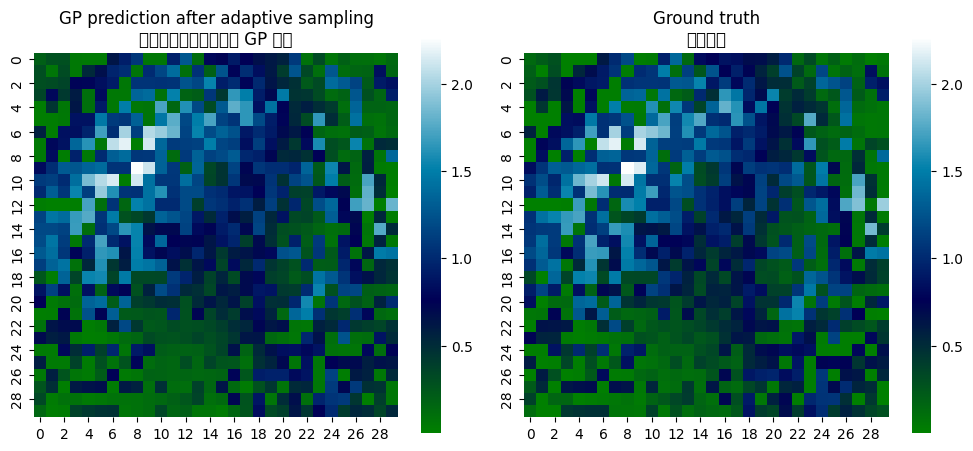

final held-out test MAE: 0.0452 (40 test plots)


In [ ]:
import pandas as pd

df = pd.DataFrame({"round": list(range(1, len(results["error"]) + 1)),
                   "test_MAE": results["error"]})
display(df)
df.to_csv("maxent_demo_test_mae.csv", index=False)
print("saved: maxent_demo_test_mae.csv")

pred = agent.predict(env.all_x).reshape(env.num_rows, env.num_cols)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.4))
vmin, vmax = env.all_y.min(), env.all_y.max()
sns.heatmap(pred, ax=axes[0], cmap="ocean", vmin=vmin, vmax=vmax, square=True)
axes[0].set_title("GP prediction after adaptive sampling\n能動サンプリング後の GP 予測")
sns.heatmap(env.all_y.reshape(env.num_rows, env.num_cols), ax=axes[1],
            cmap="ocean", vmin=vmin, vmax=vmax, square=True)
axes[1].set_title("Ground truth\n真の分布")
plt.tight_layout(); plt.show()

print("final held-out test MAE: {:.4f} ({} test plots)".format(
    results["error"][-1], len(env.test_Y)))

## 6. Interpretation, adaptations, references / 考察・修正点・参考文献

**What you just saw.** The robot greedily chose the 4 plots that most reduce the
entropy of the GP posterior, planned a budget-feasible path through the field's
corridor graph (no U-turns between crop rows), gathered accurate stop-based and
noisy on-the-move measurements along that path, and refit/evaluated a Matern GP
on the fused data. This is the paper's Section 3 method exercised on the
Section 5.1 grid simulation, using the authors' own released code and defaults.

**Differences from the paper / 論文との違い**
- Real sorghum field data is request-only from the authors; the synthetic
  mixture-of-Gaussians demo data is used (as in the authors' README demo).
- One simulation with 6 planning rounds, not the 20-simulation × 5-strategy
  benchmark (Figs. 6–7) or the noise/budget ablations (Tables 1–2).
- Compatibility fixes (Section 2) and the seed/display adaptations are mechanical;
  the numerical method is unmodified author code.
- The authors' default pilot survey covers ~75% of plots before the loop; MAE
  therefore starts low. Kept as the author default for fidelity.

**References**
- Paper: https://arxiv.org/abs/1901.06803 (arXiv:1901.06803v1)
- Code: https://github.com/sumitsk/algp @ `dfe7654` (MIT License)
- GP: gpytorch 1.13; planning graph: networkx (versions printed in Section 1).